# Figures S8A-B

In [1]:
# Import libraries
from tkinter.filedialog import askdirectory
from tkinter import Tk
import os
os.environ["OUTDATED_IGNORE"] = "1"
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import seaborn as sns

cur_dir = Path(os.getcwd())
src_dir = cur_dir.parent.parent
os.chdir(src_dir)
from functions.scale_bars import add_scalebar
os.chdir(cur_dir)

############################################################
DS_rate = 10 #standard sampling rate of input data
############################################################

plt.rcParams['figure.figsize'] = [9,10.5] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams.update({'font.size': 16})

In [2]:
###############################
# Define which stimuli to plot:
StimsToPlot = ['Sham', 'Saline']
my_colors = ['#3DC44E','#D485FF']
DS = 10 #how much to downsample for plots
###############################
# Set these variables to determine how long before each event type to plot
ContactPreTime = 3 #in mins
BitePreTime = 3 #in mins
FinishPreTime = 5 #in mins
###############################

# Convert to seconds
ContactPreTime = ContactPreTime*60
FinishPreTime = FinishPreTime*60
BitePreTime = BitePreTime*60

# Open a dialog box to select the directory to be analyzed
# (so that this code block can be run independently of the merging block above)
window = Tk()
window.wm_attributes('-topmost', 1)
window.withdraw()
Dir2 = askdirectory(parent = window)
os.chdir(Dir2 + '/')

# Load data
with open('AllTrialsData.pkl', 'rb') as f:
    AllTrials = pickle.load(f)

In [3]:
# Initialize dataframe to contain mouse means (for dF/F0 AND z-score)
my_cols = pd.MultiIndex(levels = [[],[]], codes = [[],[]],
                            names = [u'Mouse',u'Stim'])
MouseMeans_Aligned = {}
MouseMeans_Aligned['dFF0'] = {}
MouseMeans_Aligned['dFF0']['Drop'] = pd.DataFrame(index = AllTrials['Drop_dFF0'].index, columns = my_cols)
MouseMeans_Aligned['ZS'] = {}
MouseMeans_Aligned['ZS']['Drop'] = pd.DataFrame(index = AllTrials['Drop_dFF0'].index, columns = my_cols)

for Mouse in list(set(AllTrials['MouseID'])): #loop through mice
    MouseTrials_dFF0 = AllTrials['Drop_dFF0'].xs(Mouse, level=0, axis=1) # take the trials from this mouse
    MouseTrials_ZS = AllTrials['Drop_ZS'].xs(Mouse, level=0, axis=1)
    # loop through unique stimulus IDs for this mouse
    for Stim in list(set(MouseTrials_dFF0.columns.get_level_values(1))):
        # return the trials for this stimulus
        ThisStimTrials_dFF0 = MouseTrials_dFF0.xs(Stim, level=1, axis=1)
        ThisStimTrials_ZS = MouseTrials_ZS.xs(Stim, level=1, axis=1)
        # calculate mean over trials for this mouse
        ThisMouseMean_dFF0 = pd.DataFrame(np.mean(ThisStimTrials_dFF0,1), 
                                                index=list(MouseTrials_dFF0.index), columns=pd.MultiIndex.from_arrays([[Mouse],[Stim]]))
        ThisMouseMean_ZS = pd.DataFrame(np.mean(ThisStimTrials_ZS,1), 
                                                index=list(MouseTrials_ZS.index), columns=pd.MultiIndex.from_arrays([[Mouse],[Stim]]))
        # add to dataframe
        MouseMeans_Aligned['dFF0']['Drop'] = pd.concat([MouseMeans_Aligned['dFF0']['Drop'],ThisMouseMean_dFF0], axis=1)
        MouseMeans_Aligned['ZS']['Drop'] = pd.concat([MouseMeans_Aligned['ZS']['Drop'],ThisMouseMean_ZS], axis=1)
        del(ThisMouseMean_dFF0,ThisMouseMean_ZS,ThisStimTrials_dFF0,ThisStimTrials_ZS)
    del(MouseTrials_dFF0,MouseTrials_ZS)

In [4]:
# Create function that will plot mean over mice for each stimulus given a dataframe as input
# Other arguments are the stimuli to be plotted ('Stims') and a string defining the signal and event being aligned to ('Signal')

def Plot_Mean_Over_Mice(Stims, Signal, AlignedTo, MouseData = MouseMeans_Aligned):
    fig = plt.figure(figsize=[25,10.5])
    ax = fig.add_subplot(1, 1, 1)
    MouseData = MouseData[Signal][AlignedTo]
    StimN = 0
    for Stim in Stims:
        # Select trials for this stimulus
        StimTrials = MouseData.xs(Stim, level = 1, axis = 1)
        # Calculate mean over these trials and downsample
        StimMean = np.mean(StimTrials, 1)[::DS]
        # Calculate SEM and downsample
        StimSEM = np.std(StimTrials,1,ddof=1) / np.sqrt(len(StimTrials.columns))
        StimSEM = StimSEM[::DS]
        # Shade in SEM
        ax.fill_between(np.array(StimMean.index,dtype=float), np.add(StimMean,StimSEM).tolist(),
                            np.subtract(StimMean,StimSEM).tolist(), color=my_colors[StimN],
                            alpha = 0.4)
        # Plot mean trace
        ax.plot(StimMean, label = Stim, color=my_colors[StimN])
        StimN = StimN + 1
    # Plot line at t=0
    yl = list(ax.get_ylim())
    box = StimMean.loc[0:600].index
    ax.fill_between(np.array(box,dtype=float), yl[0]*len(box), yl[1]*len(box), color="gray", alpha = 0.4)
#    ax.set_ylim([y*2.5 for y in yl])
    ax.set_ylim([-11.318693742967474, 7.82187228695763])
    ax.legend(loc="lower right")
    ax.set_xlabel('time (secs)')
    ax.set_ylabel(Signal)
    ax.set_title('Mean over mice - aligned to '+AlignedTo)
    # Save this figure
    #fig.savefig(Signal+' '+AlignedTo+'Aligned' + ', '.join(StimsToPlot)+': MeanOverTrials.png')

    return fig, ax

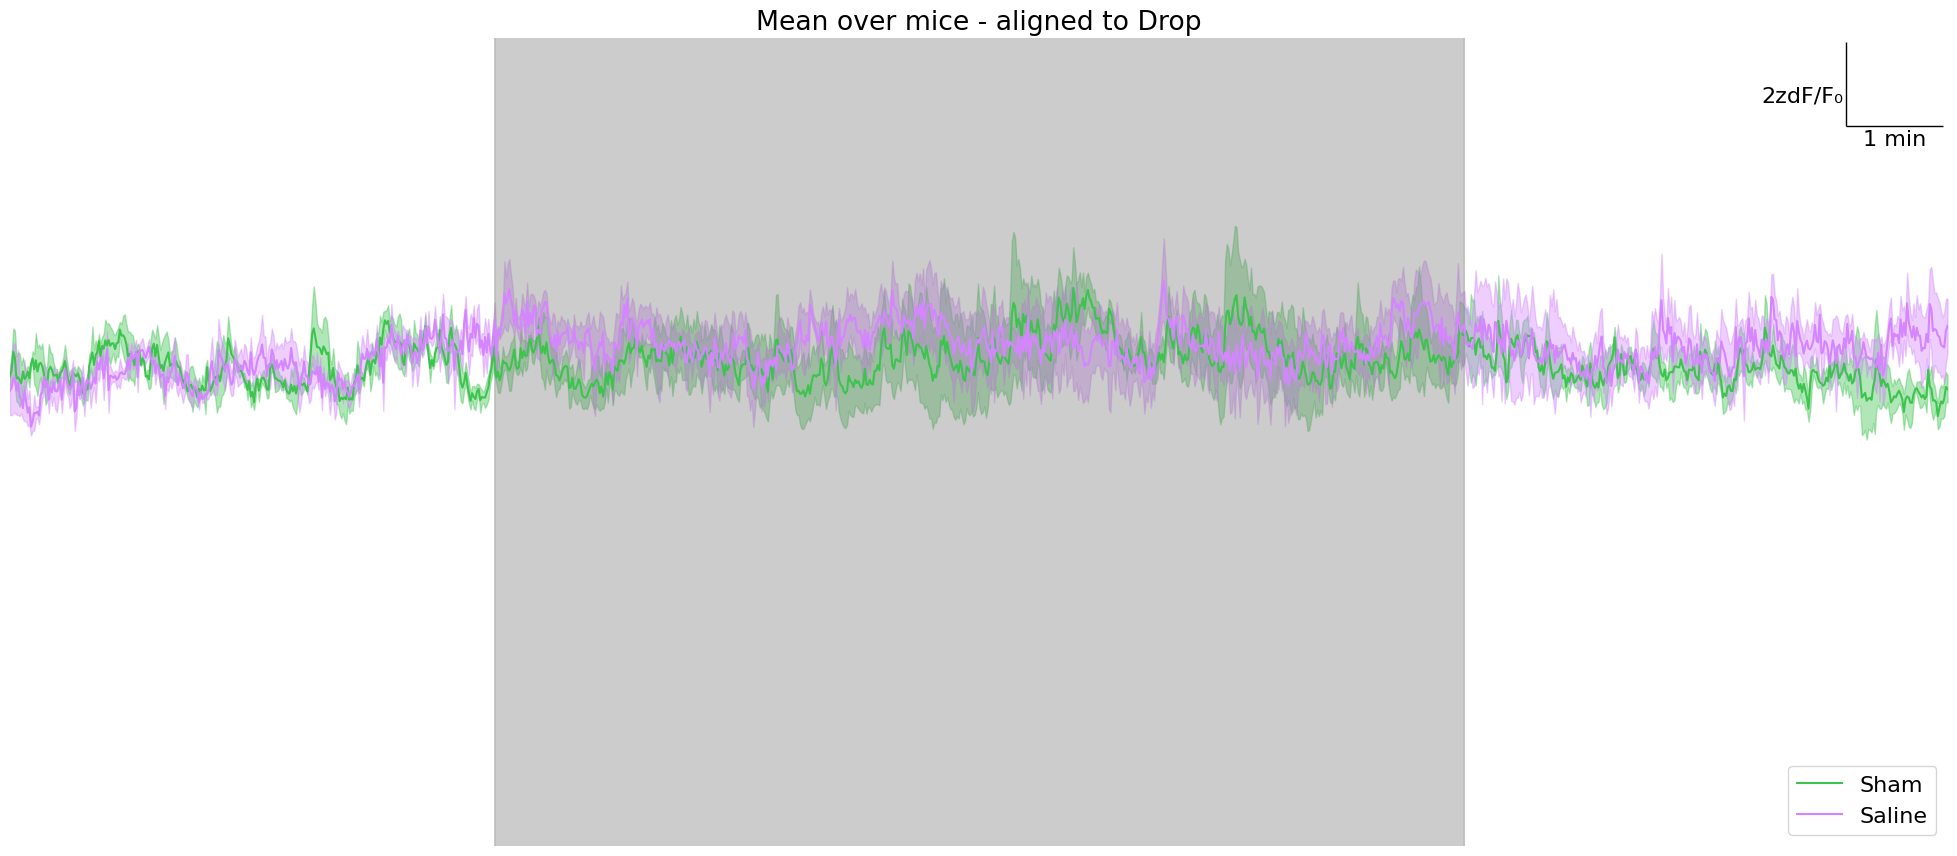

In [5]:
# Plot z-scored dF/F0 aligned to drop
fig, ax = Plot_Mean_Over_Mice(Stims = StimsToPlot, Signal = 'ZS', AlignedTo = 'Drop')
add_scalebar(ax, matchx=False, matchy=False, sizex=60, sizey=2, hidex=True, hidey=True,
             labelx='1 min', labely=u'2zdF/F\u2080', loc='upper right')
#ax.axhline(0, color='black')
#fig.savefig('zs DropAligned '+ ', '.join(StimsToPlot) + '_MeanOverMice.png')
#fig.savefig('zs DropAligned '+ ', '.join(StimsToPlot) + '_MeanOverMice.pdf')

In [6]:
multi_quants = []
periods = {"Early": [1, 60*5], "Late": [60*5+1, 60*10], "Post": [60*10+1, 60*15]}
for period, times in periods.items():
    quant = MouseMeans_Aligned['ZS']['Drop'].loc[times[0]:times[1]].mean(axis=0)
    quant = quant.unstack(level=1)
    quant = quant[quant.columns[::-1]]
    quant = quant.reset_index().melt(id_vars="Mouse", value_vars=StimsToPlot, var_name="Stim", value_name="Value").assign(Period=period)
    multi_quants.append(quant)
multi_quants = pd.concat(multi_quants, ignore_index=True)

C:\Users\sjwal\AppData\Local\Temp\ipykernel_42660\1743411284.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


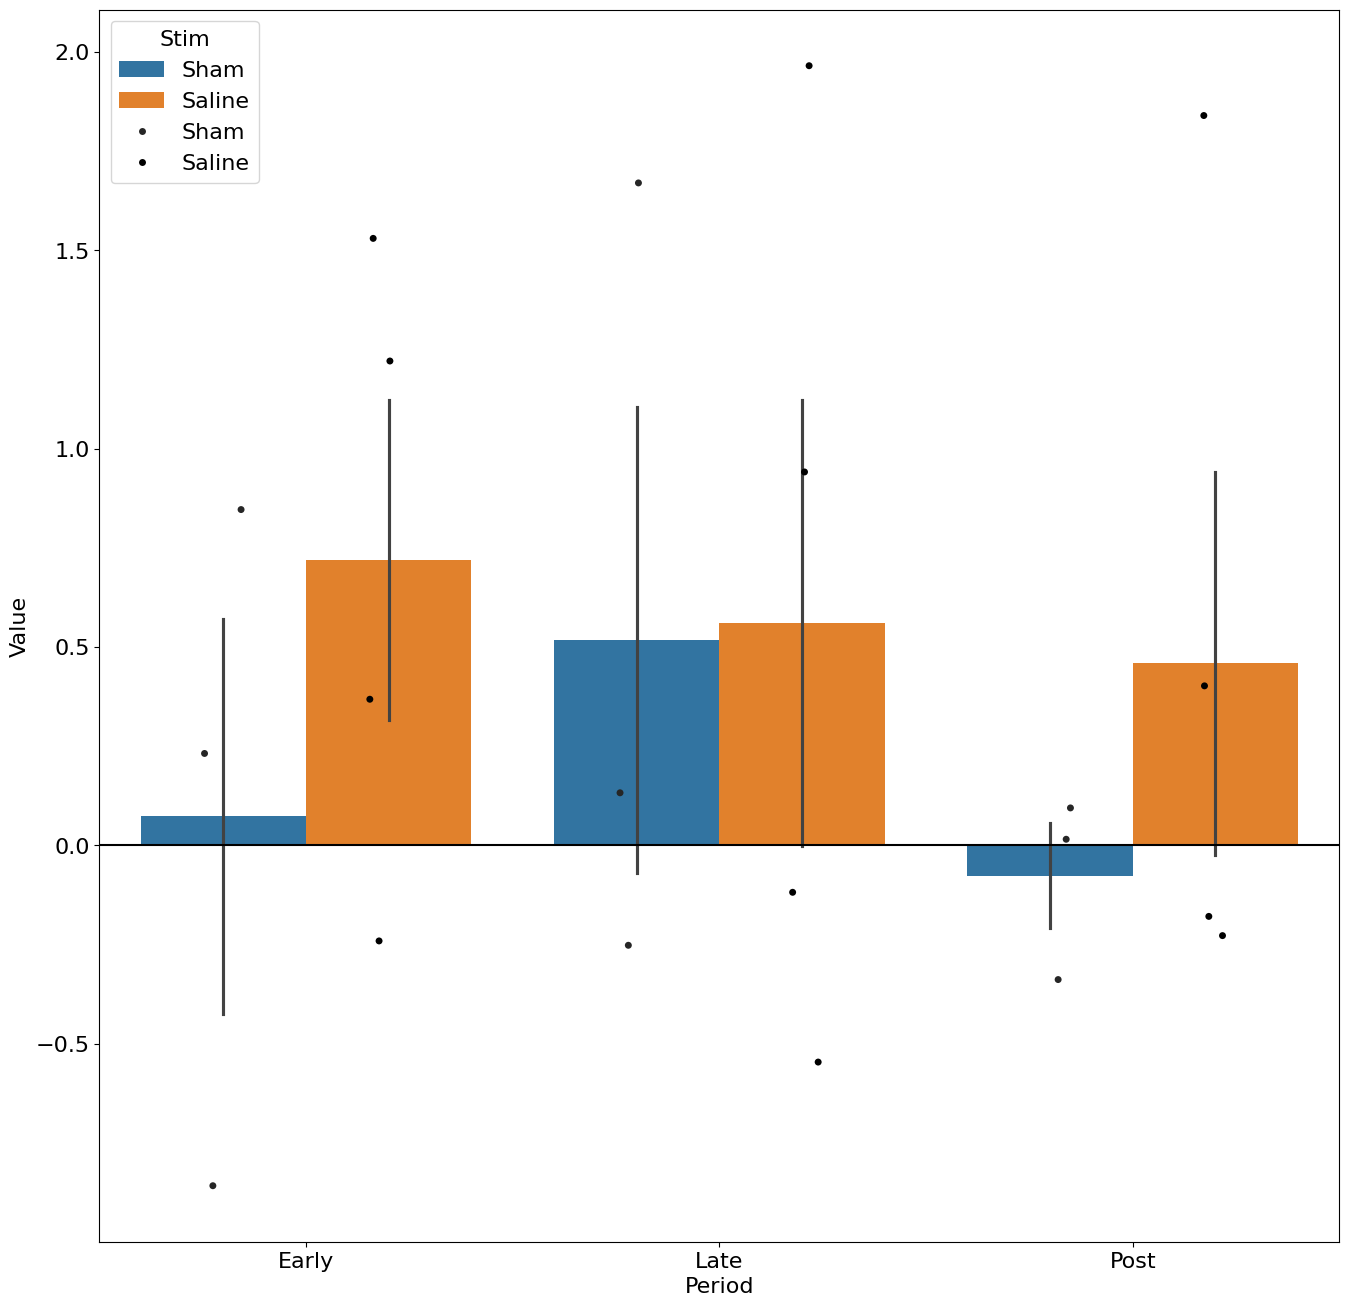

In [7]:
fig, ax = plt.subplots(1,1, figsize=(16,16))
sns.barplot(
    data=multi_quants,
    x='Period',
    y='Value',
    hue='Stim',
    ax=ax,
    errorbar='se',
)
sns.stripplot(
    data=multi_quants,
    x='Period',
    y='Value',
    hue='Stim',
    ax=ax,
    dodge=True,
    color='black'
)
ax.axhline(0, color="black")
#fig.savefig('barplot_dropaligned_mousemeans_byperiod.png')
#fig.savefig('barplot_dropaligned_mousemeans_byperiod.pdf')


In [8]:
period = "Early"
pg.anova(data=multi_quants[multi_quants["Period"]==period], dv="Value", between="Stim")

,Source,ddof1,ddof2,F,p-unc,np2
0,Stim,1,5,1.039239,0.354763,0.172081


In [9]:
period = "Late"
pg.ttest(
    x=multi_quants[(multi_quants["Period"]==period) & (multi_quants["Stim"]==StimsToPlot[0])]["Value"],
    y=multi_quants[(multi_quants["Period"]==period) & (multi_quants["Stim"]==StimsToPlot[1])]["Value"],
    paired=False
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.053662,4.712934,two-sided,0.959404,"[-2.17, 2.09]",0.040279,0.545,0.050217


In [10]:
period = "Post"
pg.ttest(
    x=multi_quants[(multi_quants["Period"]==period) & (multi_quants["Stim"]==StimsToPlot[0])]["Value"],
    y=multi_quants[(multi_quants["Period"]==period) & (multi_quants["Stim"]==StimsToPlot[1])]["Value"],
    paired=False
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-1.069911,3.444449,two-sided,0.353834,"[-2.02, 0.95]",0.703179,0.741,0.1176
